In [5]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
data = pd.read_csv("/content/smoker_train.csv")  #encoding="ISO-8859-1", on_bad_lines="skip"
data_test = pd.read_csv("/content/smoker_test.csv")
df=data.copy()
df_test=data_test.copy()
df.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,...,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,...,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,...,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,...,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,...,44,93,15.4,1,0.8,19,13,17,0,1


In [7]:
# checking testset top 5 rows
df_test.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,159256,40,165,70,84.0,1.2,1.2,1,1,130,...,186,49,115,14.2,1,0.9,19,25,32,0
1,159257,80,160,60,93.0,1.0,1.0,2,2,144,...,158,35,104,13.0,1,1.1,20,12,24,0
2,159258,60,170,70,86.5,0.6,0.7,1,1,117,...,173,39,88,15.4,1,1.4,38,60,36,0
3,159259,40,160,50,67.0,0.3,0.4,1,1,116,...,47,75,128,14.5,1,0.6,25,18,10,1
4,159260,40,170,75,89.4,1.0,0.9,1,1,132,...,100,39,123,16.5,1,1.0,30,39,27,1


In [8]:
print(df.shape,
df_test.shape)

(159256, 24) (106171, 23)


In [9]:
# checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   159256 non-null  int64  
 1   age                  159256 non-null  int64  
 2   height(cm)           159256 non-null  int64  
 3   weight(kg)           159256 non-null  int64  
 4   waist(cm)            159256 non-null  float64
 5   eyesight(left)       159256 non-null  float64
 6   eyesight(right)      159256 non-null  float64
 7   hearing(left)        159256 non-null  int64  
 8   hearing(right)       159256 non-null  int64  
 9   systolic             159256 non-null  int64  
 10  relaxation           159256 non-null  int64  
 11  fasting blood sugar  159256 non-null  int64  
 12  Cholesterol          159256 non-null  int64  
 13  triglyceride         159256 non-null  int64  
 14  HDL                  159256 non-null  int64  
 15  LDL              

In [10]:
# checking testset datatypes
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106171 entries, 0 to 106170
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   106171 non-null  int64  
 1   age                  106171 non-null  int64  
 2   height(cm)           106171 non-null  int64  
 3   weight(kg)           106171 non-null  int64  
 4   waist(cm)            106171 non-null  float64
 5   eyesight(left)       106171 non-null  float64
 6   eyesight(right)      106171 non-null  float64
 7   hearing(left)        106171 non-null  int64  
 8   hearing(right)       106171 non-null  int64  
 9   systolic             106171 non-null  int64  
 10  relaxation           106171 non-null  int64  
 11  fasting blood sugar  106171 non-null  int64  
 12  Cholesterol          106171 non-null  int64  
 13  triglyceride         106171 non-null  int64  
 14  HDL                  106171 non-null  int64  
 15  LDL              

- train test data types is correct.

In [11]:
# checking missing values
print(df.isnull().sum(),df_test.isnull().sum())

id                     0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64 id                     0
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL         

- there are no missing values.

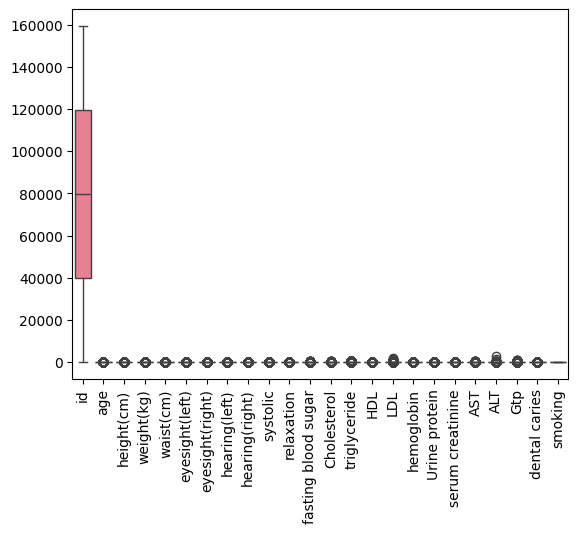

<Figure size 1500x1200 with 0 Axes>

In [12]:
# checking outlier in dataset

sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.figure(figsize=(15,12))
plt.show()

- there are no outlier.

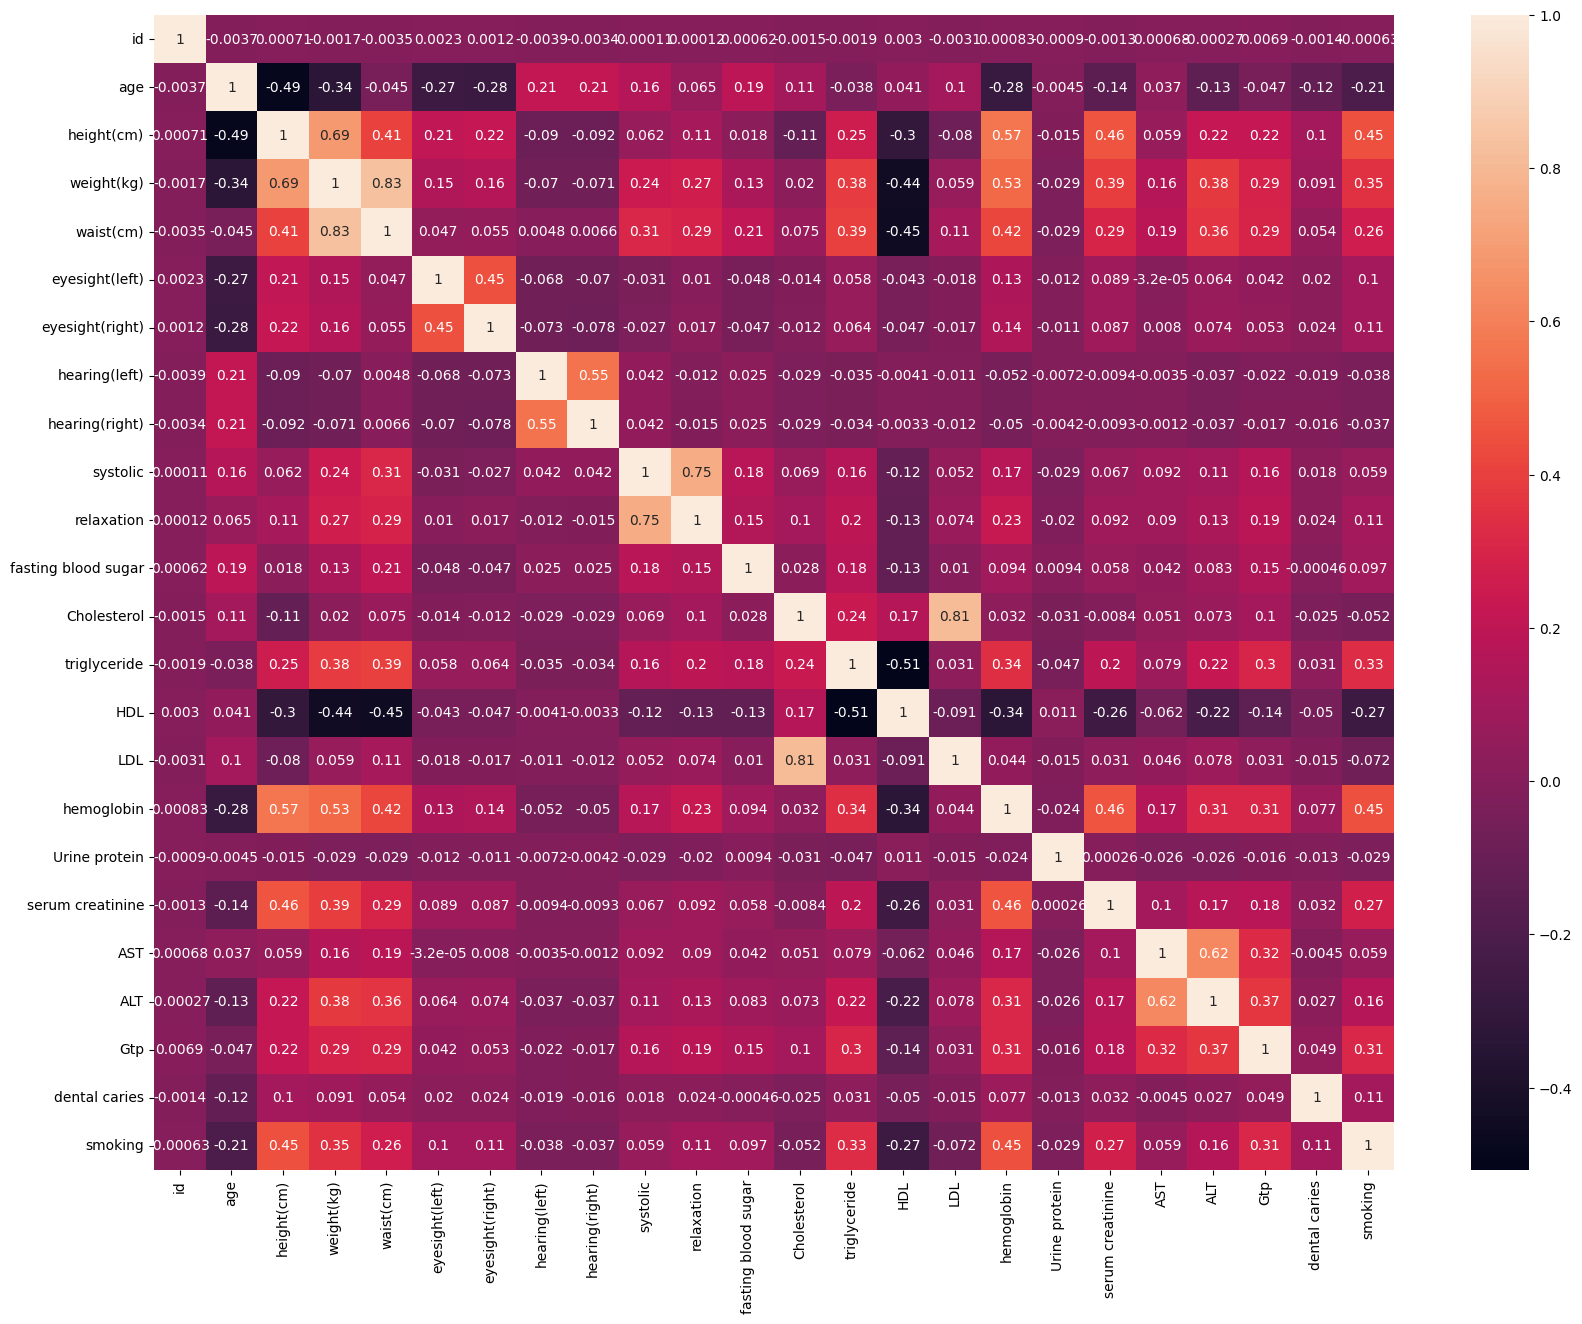

In [35]:
# checking correleation in dataset
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True);

- age is positive coreleated with himoglobin and weight.
- height is coreleated with weight.
- height is correleated with waist.
- ldl is correleated with colestrol.
- assuming all data point is real.

In [13]:
# lets drop irreleavent feature
df.drop(["id", "weight(kg)", "LDL"],axis=1,inplace=True)
df_test.drop(["id", "weight(kg)", "LDL"],axis=1,inplace=True)

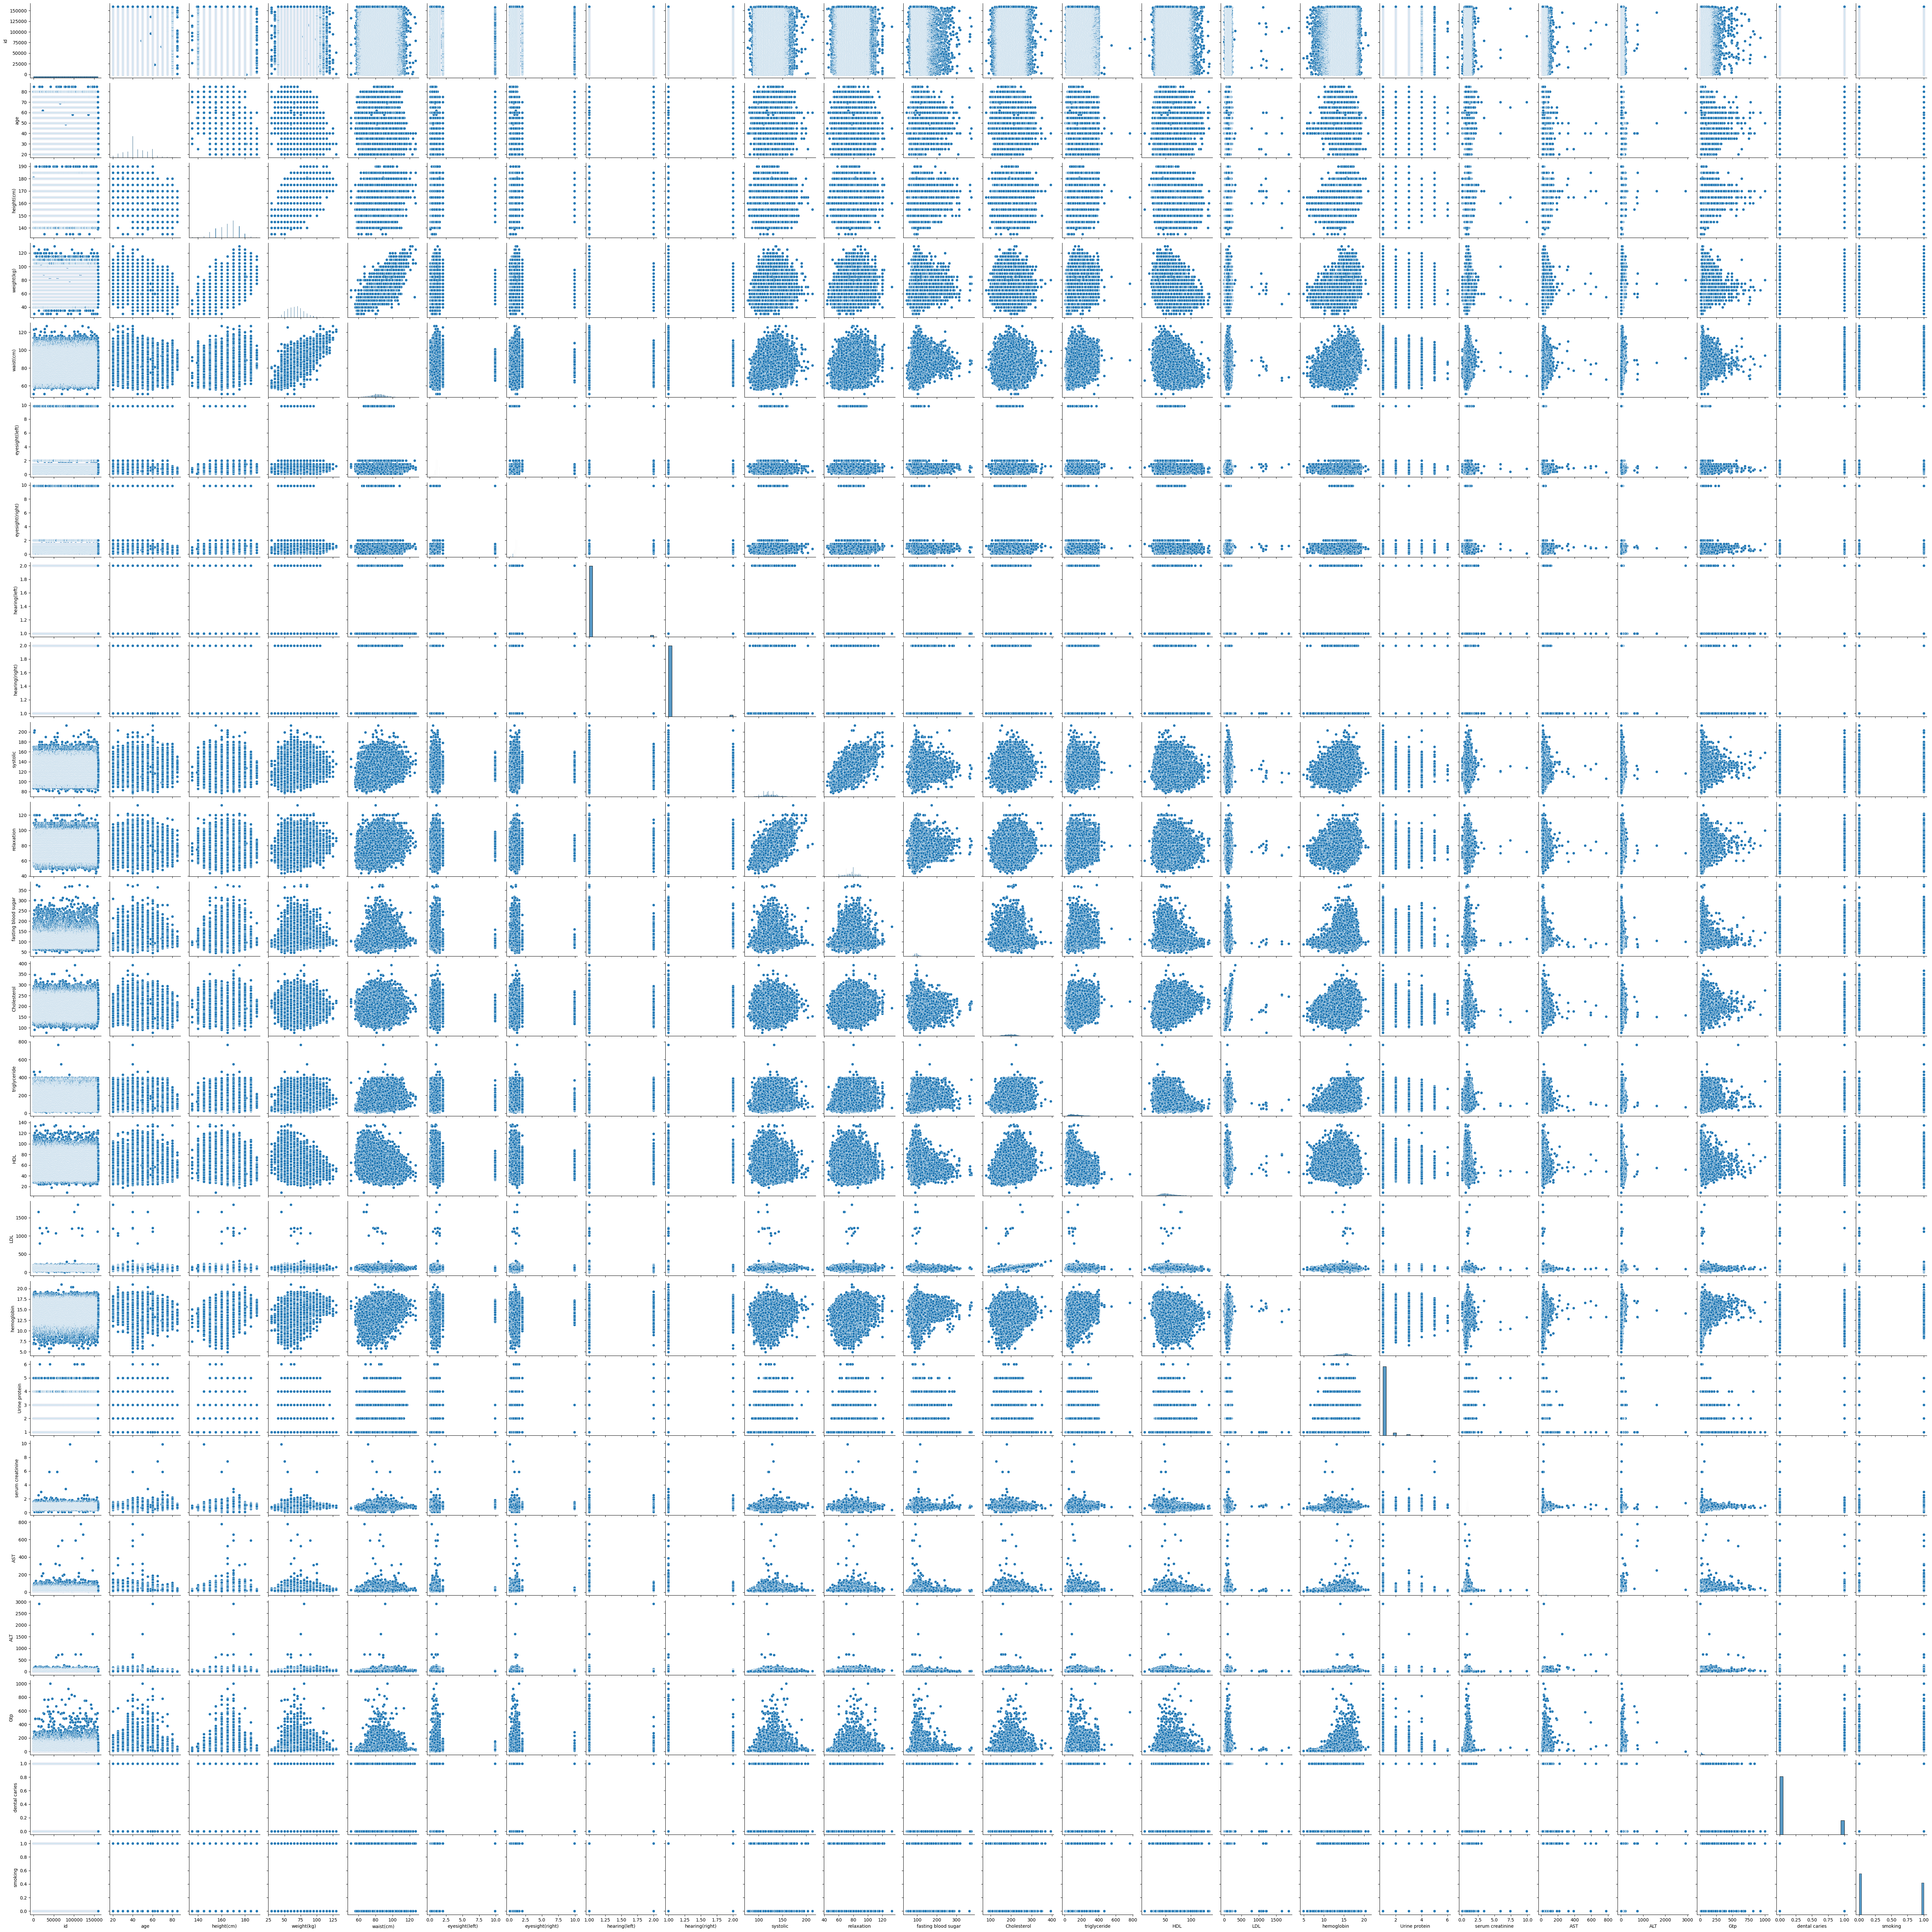

<Figure size 1500x1200 with 0 Axes>

In [36]:
# lets ckeck data distribution
sns.pairplot(df)
plt.figure(figsize=(15,12))
plt.show()

## Data Preprocessing

In [14]:
# copying data
df_copy=df.copy()

In [15]:
# seprate independent and dependent feature
X=df_copy.drop('smoking',axis=1)
y=df_copy['smoking']

In [16]:
# Initialize StandardScaler
from sklearn.preprocessing import StandardScaler # Import StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled features
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [17]:
# lets seprate data into train and validation set
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Create the model
model = Sequential()

# Input layer with Batch Normalization
model.add(Dense(256, activation='relu', kernel_initializer='he_normal', input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layers
model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model with AdamW optimizer
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=32,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Create the model
model = Sequential()

# Input layer with Batch Normalization
model.add(Dense(256, activation='relu', kernel_initializer='he_normal', input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layers
model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile the model with AdamW optimizer
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Train the model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=5,
                    batch_size=32,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=1)



Epoch 1/20
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.7380 - loss: 0.5125 - val_accuracy: 0.7613 - val_loss: 0.4760 - learning_rate: 0.0100
Epoch 2/20
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7510 - loss: 0.4904 - val_accuracy: 0.7595 - val_loss: 0.5049 - learning_rate: 0.0100
Epoch 3/20
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7518 - loss: 0.4897 - val_accuracy: 0.7305 - val_loss: 0.5213 - learning_rate: 0.0100
Epoch 4/20
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7543 - loss: 0.4863 - val_accuracy: 0.7334 - val_loss: 0.5440 - learning_rate: 0.0100
Epoch 5/20
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7537 - loss: 0.4857 - val_accuracy: 0.7517 - val_loss: 0.4854 - learning_rate: 0.0100
Epoch 6/20
3972/3982 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7555 - loss: 0.4833
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
3982/3982 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7555

- not getting good score .

In [21]:
# check accuracy,r2,precision,f1_score  in train and test set

from sklearn.metrics import accuracy_score, r2_score, precision_score, f1_score

# Make predictions on the training set
y_train_pred = (model.predict(X_train) > 0.5).astype(int)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
# Assuming you have a regression model, if it is a classification model then please comment out this line.
#train_r2 = r2_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Make predictions on the test set
y_val_pred = (model.predict(X_val) > 0.5).astype(int)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_val, y_val_pred)
# Assuming you have a regression model, if it is a classification model then please comment out this line.
#test_r2 = r2_score(y_val, y_val_pred)
test_precision = precision_score(y_val, y_val_pred)
test_f1 = f1_score(y_val, y_val_pred)

print("Training Set:")
print("Accuracy:", train_accuracy)
#print("R2 Score:", train_r2)
print("Precision:", train_precision)
print("F1 Score:", train_f1)

print("\nTest Set:")
print("Accuracy:", test_accuracy)
#print("R2 Score:", test_r2)
print("Precision:", test_precision)
print("F1 Score:", test_f1)


3982/3982 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
996/996 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Training Set:
Accuracy: 0.7701642020658692
Precision: 0.6915770765958686
F1 Score: 0.7642920389599935

Test Set:
Accuracy: 0.7673615471555946
Precision: 0.6928021309861602
F1 Score: 0.7635458548726786


996/996 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Confusion Matrix:
[[12478  5305]
 [ 2105 11964]]


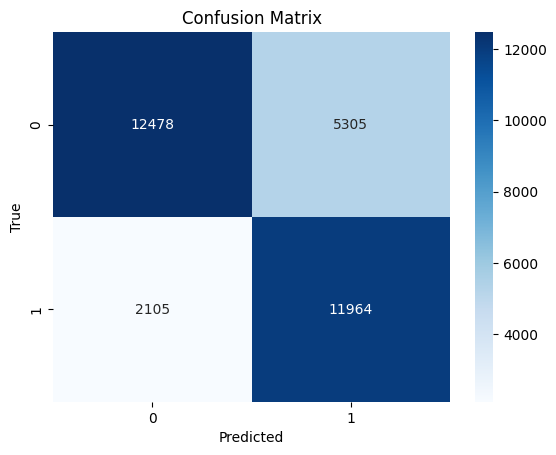

In [22]:
# check it with confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions on the validation set
y_val_pred = (model.predict(X_val) > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# You can also visualize the confusion matrix using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
